In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.35 # 0.95
e0 = 0.45 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=8.0

print(use_gpu)

True


In [4]:
SK_traj = EMRIInspiral(func=SuperKludgeFlux,use_gpu=use_gpu)
add_args= [chi2, evolve_1PA, evolve_primary, evolve_2PA,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p0_ = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
print(p0_)

7.745727381975183


In [5]:
filename= "rishav_CVBias"

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

In [6]:
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

print(use_gpu)
der_order = 8
Ndelta=8
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = True,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=True
                       )
                   

der_order = 12
Ndelta = 8
stability_plot = True

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
emri_kwargs = {"T":T, "dt":dt}
# sef.waveform_generator.backend.uses_cupy

True


In [7]:

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.35, 8.0, 0.45, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  76.32565372722452


In [8]:
# got from Shubham's code
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    params:
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

#Equation 29 of cutler-vallisneri paper
    if use_gpu:
        xp = cp
    else:
        xp = np
        
    #waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx
    delta_wave = waveform_truth - waveform_approx
    #truth contains 1 order PN and approx contains 0 order PN with deviations

    # calculate all the column-wise inner products
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar
        if not use_gpu:
            inn_prod_j = xp.asarray(inn_prod_j)
        else:
            inn_prod_j = xp.asnumpy(inn_prod_j)
            
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
    # calculate all the param shifts
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods  #should be a scalars
        print(f"{param_names[i]} have delta {delta_param_i}")
        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
    return params_truth + np.array(delta_param_all)


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.35, 8.0, 0.45, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 76.32565372722452
calculating stable deltas...
Gamma_ii for m1: 721.5375215007749
Gamma_ii for m1: 721.5375214998447
Gamma_ii for m1: 721.5375215028309
Gamma_ii for m1: 721.5375215188968
Gamma_ii for m1: 721.537521366163
Gamma_ii for m1: 721.537521446841
Gamma_ii for m1: 721.5375205767407
Gamma_ii for m1: 721.5375219615287
Gamma_ii for m1: 721.5375194015099
Gamma_ii for m1: 721.5375414779735
Gamma_ii for m1: 721.5375415266361
Gamma_ii for m1: 721.5377058692427
[np.float64(1.2891716349063942e-12), np.float64(4.138678970171854e-12), np.float64(2.2266177942465952e-11), np.float64(2.1167829554190465e-10), np.float64(1.1181397457225162e-10), np.float64(1.2058974828234252e-09), np.flo

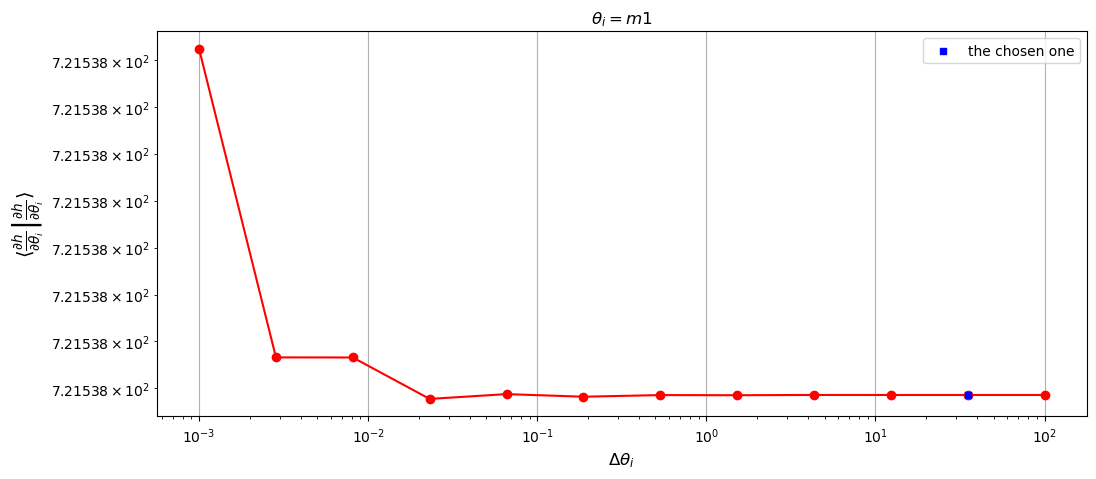

Gamma_ii for m2: 103302376027.81223
Gamma_ii for m2: 103302376024.93356
Gamma_ii for m2: 103302376057.30005
Gamma_ii for m2: 103302376014.38976
Gamma_ii for m2: 103302376281.95192
Gamma_ii for m2: 103302376355.3634
Gamma_ii for m2: 103302376162.51701
Gamma_ii for m2: 103302374113.20703
Gamma_ii for m2: 103302382666.79164
Gamma_ii for m2: 103302364402.4308
Gamma_ii for m2: 103302293912.77895
Gamma_ii for m2: 103302667567.05095
[np.float64(2.7866368811112264e-11), np.float64(3.133179199842411e-10), np.float64(4.1538534963730427e-10), np.float64(2.5900872171261633e-09), np.float64(7.106466119628327e-10), np.float64(1.8668146555227217e-09), np.float64(1.9837975650530608e-08), np.float64(8.280142615466555e-08), np.float64(1.7680486739579382e-07), np.float64(6.823628903631623e-07), np.float64(3.617082509129254e-06)]
0


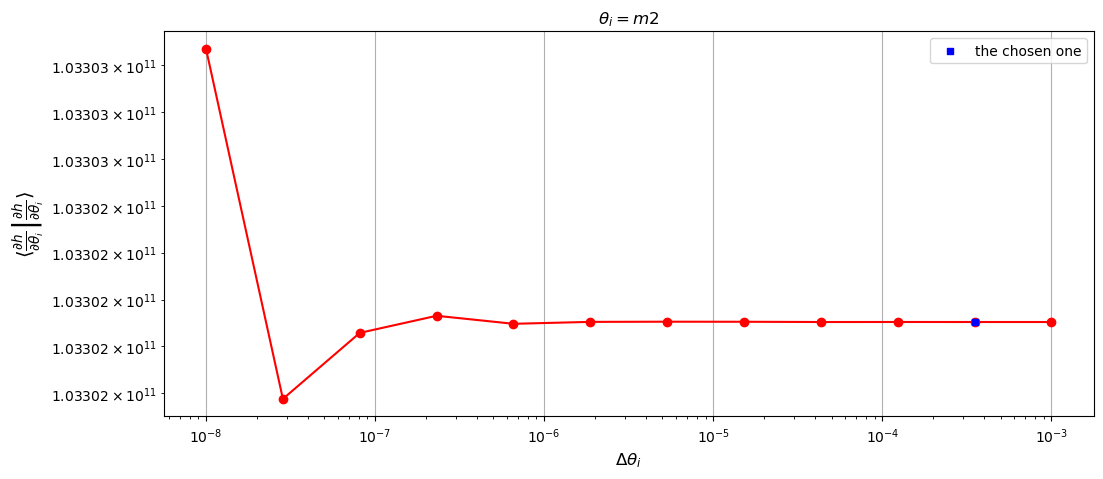

Gamma_ii for a: 10277813505861.916
Gamma_ii for a: 10277813226272.223
Gamma_ii for a: 10277814397505.975
Gamma_ii for a: 10277812359592.148
Gamma_ii for a: 10277804400526.781
Gamma_ii for a: 10277806715328.365
Gamma_ii for a: 10277908856731.268
Gamma_ii for a: 10277895329019.393
Gamma_ii for a: 10274883326586.629
Gamma_ii for a: 10274460786728.771
Gamma_ii for a: 10256141618940.389
Gamma_ii for a: 10262815947439.287
[np.float64(2.7203227690953338e-08), np.float64(1.1395747253787127e-07), np.float64(1.9828284024565954e-07), np.float64(7.743935433116011e-07), np.float64(2.2522330377473142e-07), np.float64(9.937955699563216e-06), np.float64(1.3161947501843912e-06), np.float64(0.000293142251549466), np.float64(4.112525870001904e-05), np.float64(0.0017861656428916836), np.float64(0.000650340855090924)]
0


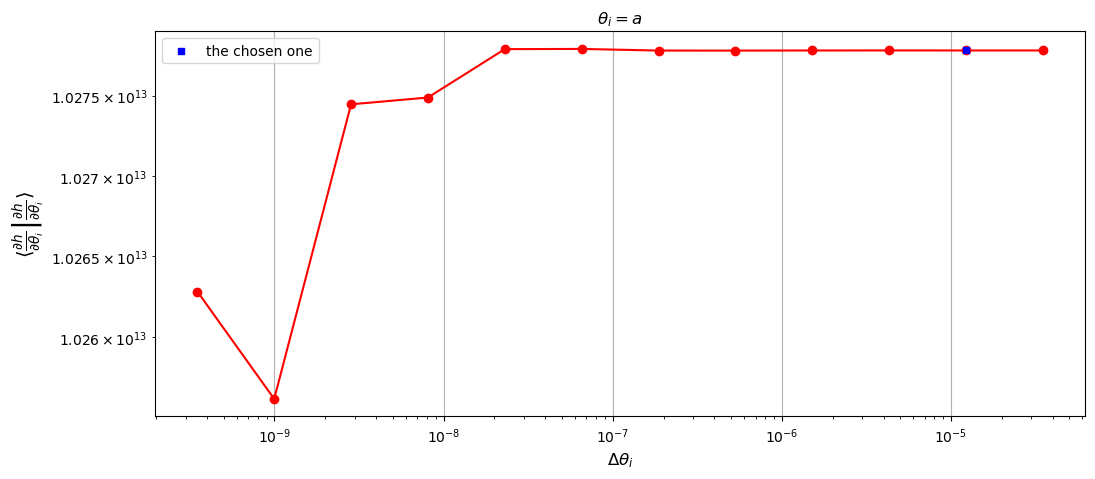

Gamma_ii for p0: 28390197111067.777
Gamma_ii for p0: 28390196820064.438
Gamma_ii for p0: 28390197252174.01
Gamma_ii for p0: 28390195094047.5
Gamma_ii for p0: 28390201897918.484
Gamma_ii for p0: 28390191538743.773
Gamma_ii for p0: 28390219478940.473
Gamma_ii for p0: 28390301735496.95
Gamma_ii for p0: 28390078431353.406
Gamma_ii for p0: 28390662000775.777
Gamma_ii for p0: 28388083431922.297
Gamma_ii for p0: 28385035170736.7
[np.float64(1.0250134639365614e-08), np.float64(1.5220379428172543e-08), np.float64(7.601661434764986e-08), np.float64(2.396556040298483e-07), np.float64(3.6488569289152036e-07), np.float64(9.841486685210184e-07), np.float64(2.897347032198517e-06), np.float64(7.865569800482e-06), np.float64(2.0554977631558844e-05), np.float64(9.083279114858728e-05), np.float64(0.0001073897272722154)]
0


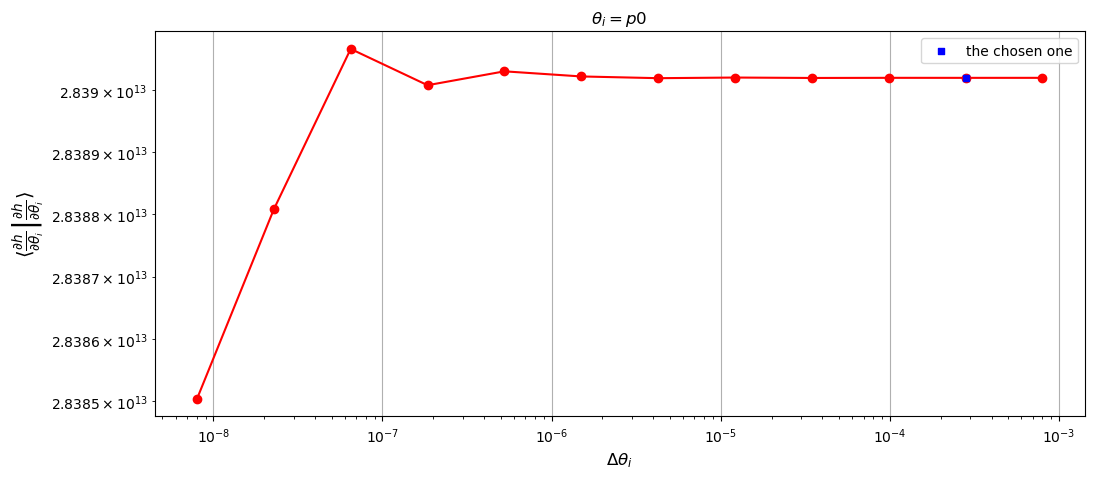

Gamma_ii for e0: 418772930813208.2
Gamma_ii for e0: 418772919657443.7
Gamma_ii for e0: 418772942786665.56
Gamma_ii for e0: 418772773017724.8
Gamma_ii for e0: 418772265991656.2
Gamma_ii for e0: 418773926066128.6
Gamma_ii for e0: 418773132434310.8
Gamma_ii for e0: 418764903439351.9
Gamma_ii for e0: 418778158250311.4
Gamma_ii for e0: 418702366321299.75
Gamma_ii for e0: 418853162882385.75
Gamma_ii for e0: 418551179689909.56
[np.float64(2.663917358630882e-08), np.float64(5.523093665290277e-08), np.float64(4.053963191700011e-07), np.float64(1.210744143775515e-06), np.float64(3.9641304510810385e-06), np.float64(1.8951354715598664e-06), np.float64(1.965063187328275e-05), np.float64(3.165115156645146e-05), np.float64(0.00018101624234305027), np.float64(0.0003600224958271206), np.float64(0.0007214964552242253)]
0


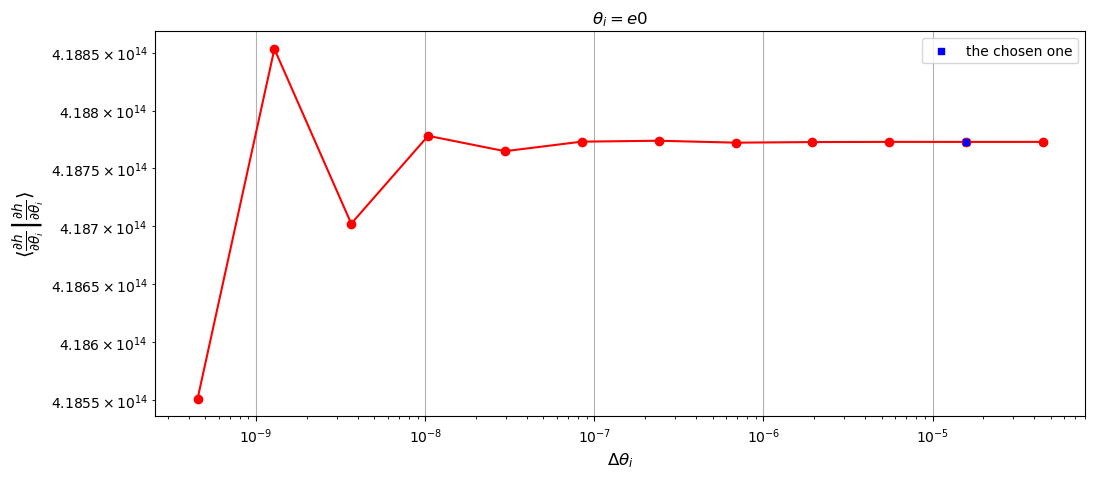

Gamma_ii for qS: 18005.35096574012
Gamma_ii for qS: 18005.350993530687
Gamma_ii for qS: 18005.35099353742
Gamma_ii for qS: 18005.350993537344
Gamma_ii for qS: 18005.35099353677
Gamma_ii for qS: 18005.35099354111
Gamma_ii for qS: 18005.350993537075
Gamma_ii for qS: 18005.350993567754
Gamma_ii for qS: 18005.350993524735
Gamma_ii for qS: 18005.350993839
Gamma_ii for qS: 18005.35099354456
Gamma_ii for qS: 18005.350994160945
[np.float64(1.543461574899774e-09), np.float64(3.739943072669746e-13), np.float64(4.2430472461407346e-15), np.float64(3.192387928048845e-14), np.float64(2.410454935545161e-13), np.float64(2.2407330457000692e-13), np.float64(1.703886544125923e-12), np.float64(2.3892396993166348e-12), np.float64(1.7454077921510787e-11), np.float64(1.6352906136488702e-11), np.float64(3.423330928041553e-11)]
2


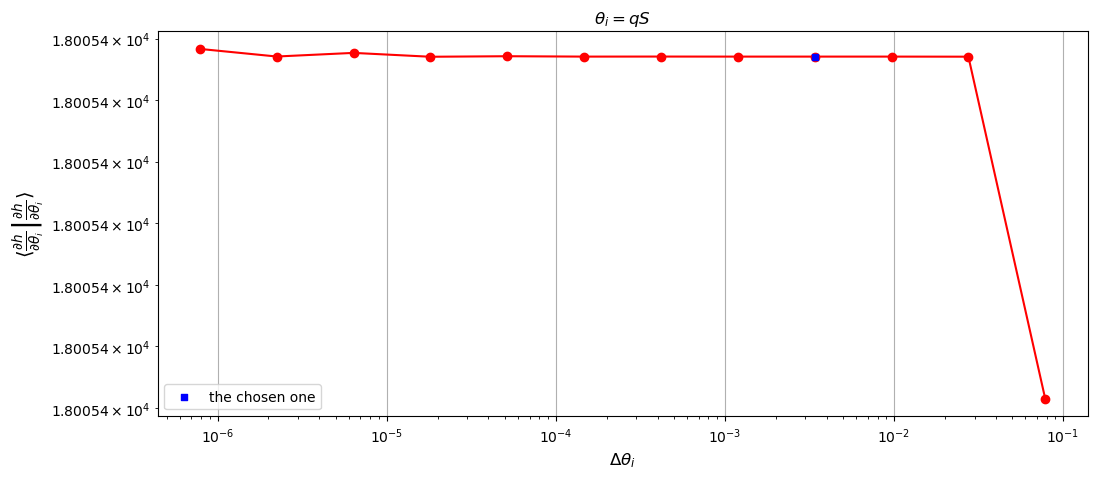

Gamma_ii for phiS: 345210.543725473
Gamma_ii for phiS: 345210.54371754924
Gamma_ii for phiS: 345210.5437175474
Gamma_ii for phiS: 345210.5437175474
Gamma_ii for phiS: 345210.5437175474
Gamma_ii for phiS: 345210.5437175474
Gamma_ii for phiS: 345210.54371754715
Gamma_ii for phiS: 345210.54371754796
Gamma_ii for phiS: 345210.5437175484
Gamma_ii for phiS: 345210.5437175478
Gamma_ii for phiS: 345210.5437175469
Gamma_ii for phiS: 345210.5437175515
[np.float64(2.2953385453291966e-11), np.float64(5.395678617380182e-15), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(6.744598271725233e-16), np.float64(2.360609395103826e-15), np.float64(1.3489196543450414e-15), np.float64(1.8547645247244357e-15), np.float64(2.529224351896964e-15), np.float64(1.3320581586657165e-14)]
2


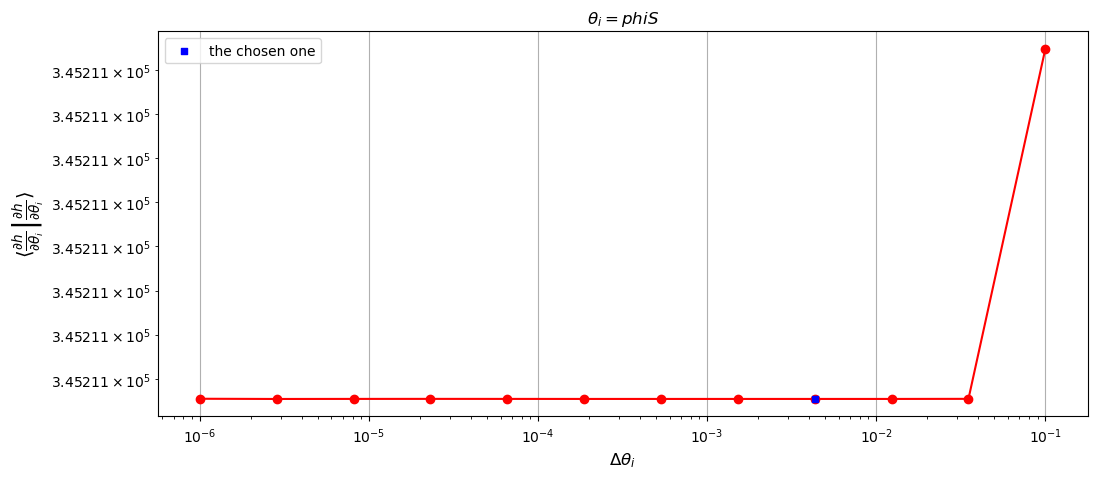

Gamma_ii for dev0p: 6345120350766.984
Gamma_ii for dev0p: 6345121010554.518
Gamma_ii for dev0p: 6345119975434.04
Gamma_ii for dev0p: 6345127432100.752
Gamma_ii for dev0p: 6345119385099.587
Gamma_ii for dev0p: 6345131106520.272
Gamma_ii for dev0p: 6345110455395.262
Gamma_ii for dev0p: 6344775686201.599
Gamma_ii for dev0p: 6345477332522.542
Gamma_ii for dev0p: 6344596821771.435
Gamma_ii for dev0p: 6359430480118.584
Gamma_ii for dev0p: 6315239792347.859
[np.float64(1.0398344367359266e-07), np.float64(1.6313647047599831e-07), np.float64(1.1751799773460658e-06), np.float64(1.2682190320856767e-06), np.float64(1.8473094548829597e-06), np.float64(3.2546517757121925e-06), np.float64(5.2762967553152514e-05), np.float64(0.00011057423802417576), np.float64(0.0001387811985287948), np.float64(0.0023325450908731078), np.float64(0.006997467906803827)]
0


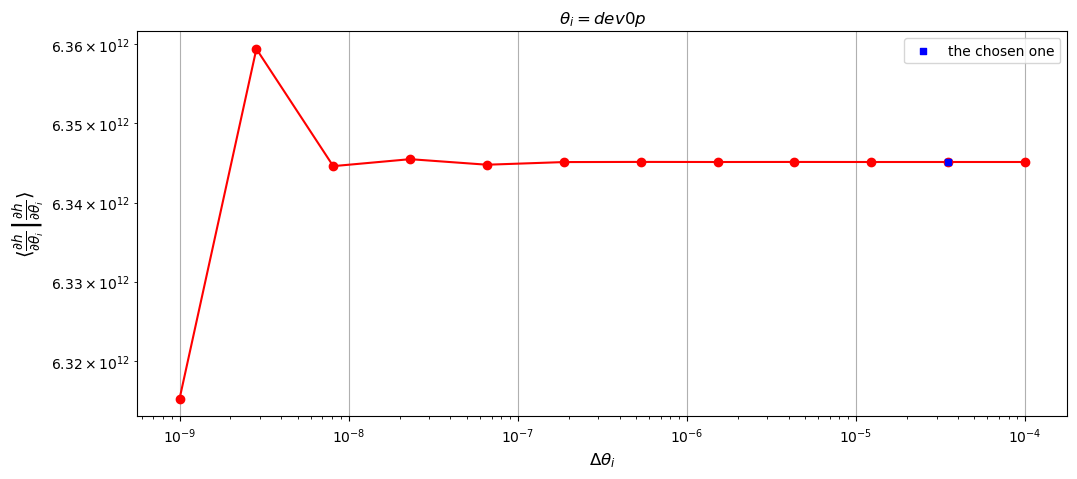

Gamma_ii for dev0e: 497322477137.8915
Gamma_ii for dev0e: 497322392665.6623
Gamma_ii for dev0e: 497322381594.69507
Gamma_ii for dev0e: 497323232607.353
Gamma_ii for dev0e: 497326189699.8829
Gamma_ii for dev0e: 497319113521.8468
Gamma_ii for dev0e: 497319770599.36115
Gamma_ii for dev0e: 497249460193.9305
Gamma_ii for dev0e: 497179067976.37555
Gamma_ii for dev0e: 497904256789.6491
Gamma_ii for dev0e: 494675253869.7397
Gamma_ii for dev0e: 499144201567.75336
[np.float64(1.6985406334558584e-07), np.float64(2.226114816835983e-08), np.float64(1.711186210821718e-06), np.float64(5.945981915070032e-06), np.float64(1.4228646846007311e-05), np.float64(1.3212374676988274e-06), np.float64(0.00014139865612572522), np.float64(0.00014158322843607017), np.float64(0.0014564824529707365), np.float64(0.006527520620143454), np.float64(0.008953219698790914)]
1


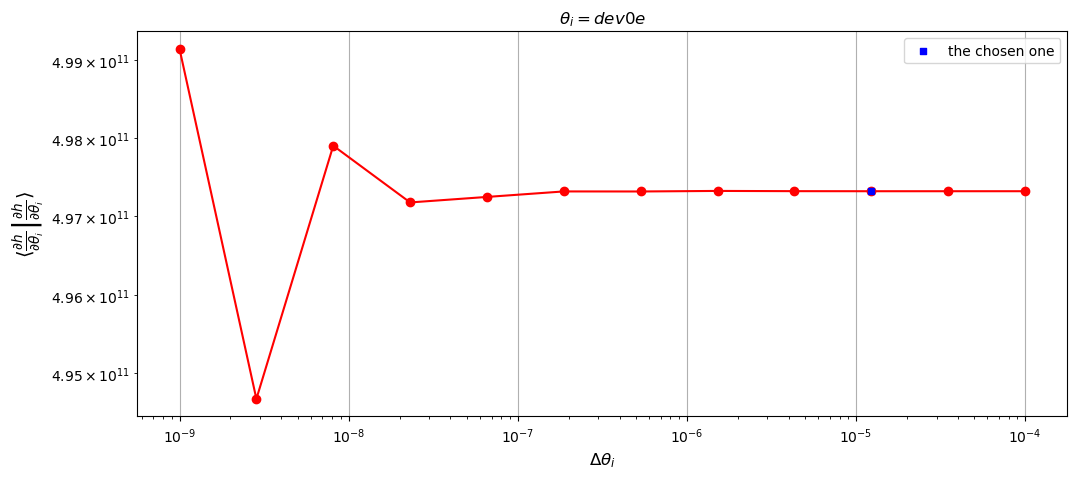

stable deltas: {'m1': 35.11191734215131, 'm2': 0.0003511191734215131, 'a': 1.2289171069752972e-05, 'p0': 0.0002808953387372106, 'e0': 1.5800362803968117e-05, 'qS': 0.00339980115994862, 'phiS': 0.004328761281083062, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 3.511191734215135e-05, 'dev0e': 1.2328467394420658e-05}
Time taken to compute stable deltas is 162.70565247535706 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 14.117499351501465 seconds


In [9]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}
der_order = 8
Ndelta = 12

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [10]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J

In [11]:
Fisher[-1].shape

(11, 11)

In [12]:
fisher_=Fisher[-1].copy()
fisher_
# sef.deltas["Phi_phi0"] = 1e-5
# sef.deltas["Phi_r0"] = 1e-5
sef.deltas

{'m1': 35.11191734215131,
 'm2': 0.0003511191734215131,
 'a': 1.2289171069752972e-05,
 'p0': 0.0002808953387372106,
 'e0': 1.5800362803968117e-05,
 'qS': 0.00339980115994862,
 'phiS': 0.004328761281083062,
 'Phi_phi0': 0.0,
 'Phi_r0': 0.0,
 'dev0p': 3.511191734215135e-05,
 'dev0e': 1.2328467394420658e-05}

In [13]:
#in this code cell, we are transfroming fisher for numerical stability and will remove parameters that are causing problem

print("Transforming to log-mass")
Fisher_transform = logmasstransform(fisher_, m1)
print("Checking log-mass Fisher positive-definiteness...")
check_flag = True
rows_to_remove = []
for j in range(len(param_names)):
    if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

rows_to_remove = np.array(rows_to_remove)
    
if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(np.delete(Fisher_transform,rows_to_remove,axis=0),rows_to_remove,axis=1)
    #Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

if (np.linalg.eigvals(Fisher_transform) < 0.0).any():
    check_flag = False
    print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")
pd.DataFrame(Fisher_transform)

Transforming to log-mass
Checking log-mass Fisher positive-definiteness...
positive-definiteness check passed!


,0,1,2,3,4,5,6,7,8,9,10
0,7.215375e+14,-8.376901e+12,6.462806e+13,1.425842e+14,5.446162e+14,-2.940758e+09,1.354573e+10,-3.552429e+09,-4.322290e+09,-6.500913e+13,-1.876794e+13
1,-8.376901e+12,1.033024e+11,-8.792943e+11,-1.683715e+12,-6.107911e+12,3.090515e+07,-1.423313e+08,3.732864e+07,4.257485e+07,8.089228e+11,2.241951e+11
2,6.462806e+13,-8.792943e+11,1.027781e+13,1.375108e+13,4.441809e+13,-2.336509e+08,1.074762e+09,-2.821067e+08,-1.957412e+08,-7.028984e+12,-1.764694e+12
3,1.425842e+14,-1.683715e+12,1.375108e+13,2.839020e+13,1.066618e+14,-5.743520e+08,2.645263e+09,-6.937857e+08,-8.118465e+08,-1.311122e+13,-3.727525e+12
4,5.446162e+14,-6.107911e+12,4.441809e+13,1.066618e+14,4.187729e+14,-2.342347e+09,1.078992e+10,-2.829670e+09,-3.538758e+09,-4.715490e+13,-1.393027e+13
5,-2.940758e+09,3.090515e+07,-2.336509e+08,-5.743520e+08,-2.342347e+09,1.800535e+04,-7.470496e+04,1.959518e+04,2.393152e+04,2.378386e+08,7.124309e+07
6,1.354573e+10,-1.423313e+08,1.074762e+09,2.645263e+09,1.078992e+10,-7.470496e+04,3.452105e+05,-9.026391e+04,-1.102639e+05,-1.095288e+09,-3.281747e+08
7,-3.552429e+09,3.732864e+07,-2.821067e+08,-6.937857e+08,-2.829670e+09,1.959518e+04,-9.026391e+04,2.368012e+04,2.891021e+04,2.872645e+08,8.606116e+07
8,-4.322290e+09,4.257485e+07,-1.957412e+08,-8.118465e+08,-3.538758e+09,2.393152e+04,-1.102639e+05,2.891021e+04,4.355720e+04,3.224755e+08,1.033204e+08
9,-6.500913e+13,8.089228e+11,-7.028984e+12,-1.311122e+13,-4.715490e+13,2.378386e+08,-1.095288e+09,2.872645e+08,3.224755e+08,6.345121e+12,1.744839e+12


In [14]:
delats=sef.deltas
param_name = sef.param_names

In [15]:
parameters = {}
for i in range(len(param_names_com)):
    parameters[param_names_com[i]] = pars_list_com[i]


order = 8 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative
parameters

{'m1': 1000000.0,
 'm2': 10,
 'a': 0.35,
 'p0': 8.0,
 'e0': 0.45,
 'xI0': 1.0,
 'dist': 0.4,
 'qS': 0.7853981633974483,
 'phiS': 1.0,
 'qK': 1,
 'phiK': 1.0471975511965976,
 'Phi_phi0': 0.9,
 'Phi_theta0': 0.5,
 'Phi_r0': 0.4,
 'chi2': 0.0,
 'evolve_1PA': False,
 'evolve_primary': False,
 'evolve_2PA': False,
 'deviation_included': True,
 'dev0p': 0.0,
 'dev0e': 0.0,
 'dev1p': 0.0,
 'dev1e': 0.0,
 'dev2p': 0.0,
 'dev2e': 0.0}

In [16]:
# del sef
sef.wave_params_list

[1000000.0,
 10,
 0.35,
 8.0,
 0.45,
 1.0,
 0.4,
 0.7853981633974483,
 1.0,
 1,
 1.0471975511965976,
 0.9,
 0.5,
 0.4,
 0.0,
 False,
 False,
 False,
 True,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [17]:
sef.waveform_derivative_kwargs

{'parameters': {'m1': 1000000.0,
  'm2': 10,
  'a': 0.35,
  'p0': 8.0,
  'e0': 0.45,
  'xI0': 1.0,
  'dist': 0.4,
  'qS': 0.7853981633974483,
  'phiS': 1.0,
  'qK': 1,
  'phiK': 1.0471975511965976,
  'Phi_phi0': 0.9,
  'Phi_theta0': 0.5,
  'Phi_r0': 0.4,
  'chi2': 0.0,
  'evolve_1PA': False,
  'evolve_primary': False,
  'evolve_2PA': False,
  'deviation_included': True,
  'dev0p': 0.0,
  'dev0e': 0.0,
  'dev1p': 0.0,
  'dev1e': 0.0,
  'dev2p': 0.0,
  'dev2e': 0.0},
 'order': 8,
 'dt': 10.0,
 'T': 0.5}

In [18]:
print(f"Calculating Cutler-Vallisneri Biases")
removed_params = []
print(f'calculating derivatives at {param_names}...')
#Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
dtv = []

for k in range(sef.npar):
        temp=sef.derivative(*sef.wave_params_list,
                             param_to_vary=sef.param_names[k],
                               delta=sef.deltas[sef.param_names[k]],
                               kind=kind, **sef.waveform_derivative_kwargs,use_gpu=use_gpu)
        print(temp)
        print("\n",temp.shape)
        print(f"calculting derivative for {sef.param_names[k]}\n")
        dtv_=np.vstack([temp.real,temp.imag])
        print(dtv_)
        dtv.append(dtv_)
        

print("Finished derivatives")
if sef.use_gpu:
        dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
          
#Jacobian transform to log-masses
for k in range(sef.npar):
    if sef.param_names[k] == 'm1':
        dtv[k] *= m1 #to obtain \partial_{log m1}h

Calculating Cutler-Vallisneri Biases
calculating derivatives at ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev0p', 'dev0e']...
[ 1.27766706e-32+1.03987973e-32j  1.81650156e-28-1.11790322e-28j
  3.91678494e-28-1.11627383e-28j ... -9.81167923e-23-5.75573934e-22j
  1.01518452e-22-5.71217210e-22j  2.84806569e-22-4.98227714e-22j]

 (1577908,)
calculting derivative for m1

[[ 1.27766706e-32  1.81650156e-28  3.91678494e-28 ... -9.81167923e-23
   1.01518452e-22  2.84806569e-22]
 [ 1.03987973e-32 -1.11790322e-28 -1.11627383e-28 ... -5.75573934e-22
  -5.71217210e-22 -4.98227714e-22]]
[ 1.27766721e-22+1.03987941e-22j  9.43599064e-23+1.31695435e-22j
  5.63158248e-23+1.48466556e-22j ...  1.58137077e-18+8.56604231e-18j
 -1.38738540e-18+8.60279009e-18j -4.17092607e-18+7.61759218e-18j]

 (1577908,)
calculting derivative for m2

[[ 1.27766721e-22  9.43599064e-23  5.63158248e-23 ...  1.58137077e-18
  -1.38738540e-18 -4.17092607e-18]
 [ 1.03987941e-22  1.31695435e-22  1.48466556e-

In [19]:
params_truth_in = np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_transformed = np.array([np.log(m1), m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])

# param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, dev_0_p, dev_0_e])
print(params_truth_in_considered)
waveform_approx = sef.waveform
waveform_approx

[13.81551056 10.          0.35        8.          0.45        0.78539816
  1.          0.9         0.4         0.          0.        ]


array([[ 6.38839992e-22,  4.71803260e-22,  2.81579822e-22, ...,
         9.14454022e-22,  9.12585598e-22,  8.06445254e-22],
       [-5.19944903e-22, -6.58484339e-22, -7.42340753e-22, ...,
         1.52267792e-22, -1.59932096e-22, -4.50308658e-22]],
      shape=(2, 1577908))

In [20]:
#initializing the 1PA (True GR model in our analysis)
evolve_1PA = True 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)
waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)


[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [21]:
waveform_true

array([[ 6.38839992e-22,  4.71801910e-22,  2.81576951e-22, ...,
        -6.70500030e-22, -6.47491227e-22, -5.95284002e-22],
       [-5.19944903e-22, -6.58485131e-22, -7.42341495e-22, ...,
        -5.47435456e-23,  9.27254527e-23,  2.23402630e-22]],
      shape=(2, 1577908))

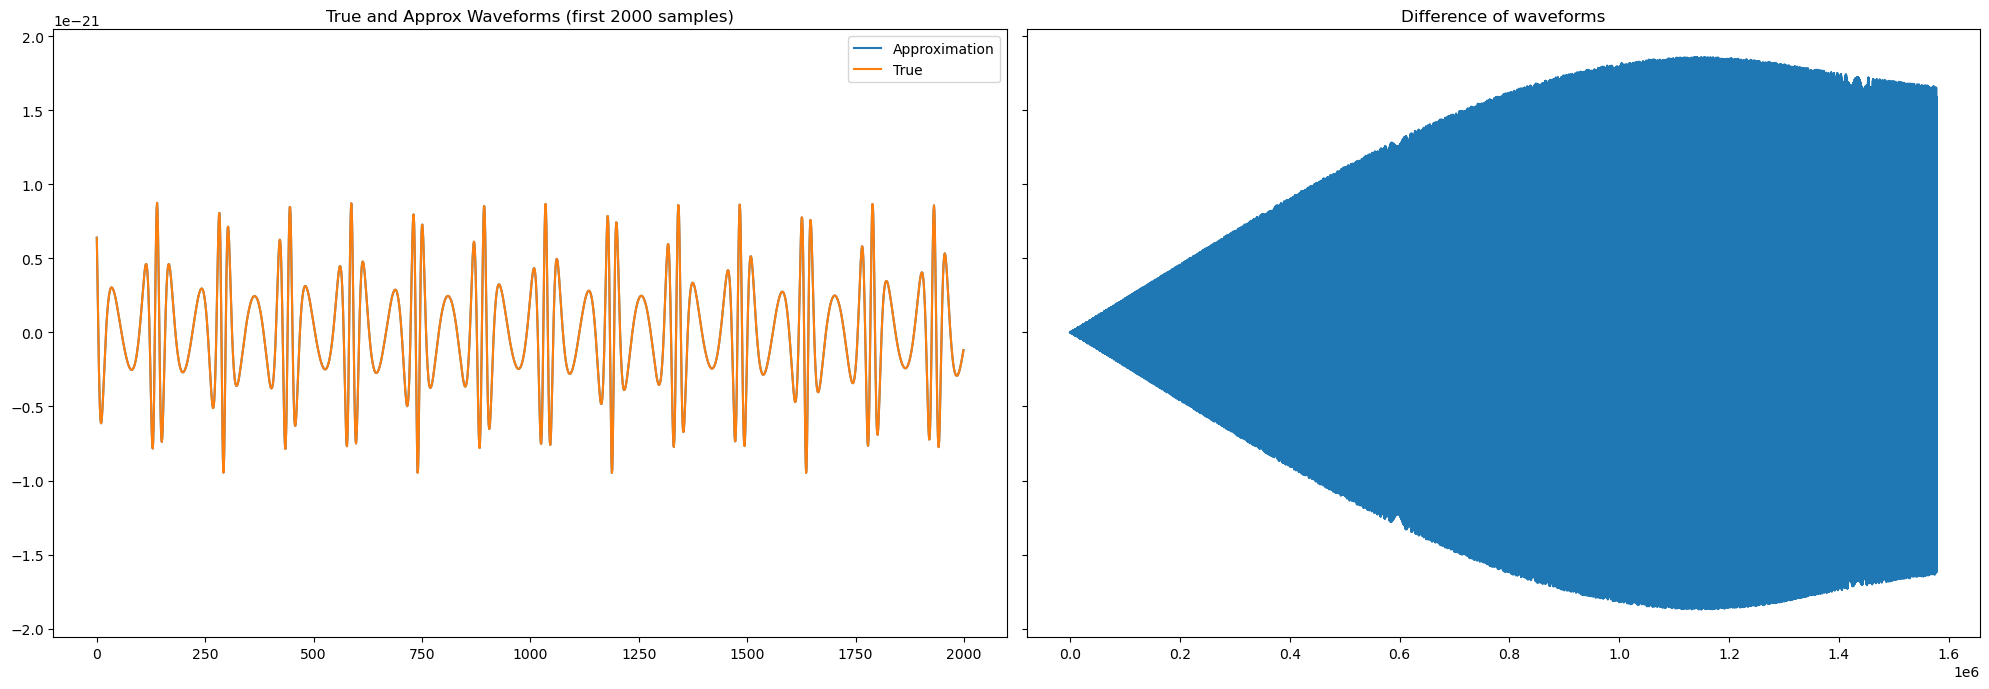

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot the first 2000 samples of both waveforms
axs[0].plot(waveform_approx[0][0:2000].get(), label="Approximation")
axs[0].plot(waveform_true[0][0:2000].get(), label="True")
axs[0].set_title("True and Approx Waveforms (first 2000 samples)")
axs[0].legend()

# Plot the difference
axs[1].plot(((waveform_true[0] - waveform_approx[0])[0:]).get())
axs[1].set_title("Difference of waveforms")

plt.tight_layout()

In [23]:
biased_params = cutlervallis(waveform_truth=waveform_true, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transform, partial_approx=dtv,
                                 params_truth=params_truth_in_considered, PSD_func = sef.PSD_funcs, dt = dt,
                                  use_gpu=use_gpu)
print(biased_params)

if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

#prior box on chi2
# if 'chi2' not in removed_params:
#     index_chi2 = np.where(param_names == 'chi2')
        
#     if biased_params[index_chi2] > 1.0:
#         biased_params[index_chi2] = 1.0
#     elif biased_params[index_chi2] < -1.0:
#         biased_params[index_chi2] = -1.0

#prior box on cyclic parameters (phases and such)
cyclic_priors = {'qS' : np.pi, 'phiS' : 2 * np.pi, 'qK' : np.pi, 'phiK' : 2 * np.pi, 'Phi_phi0' : 2 * np.pi, 'Phi_r0' : 2 * np.pi}
param_names_in = np.array(param_names)
for param in list(cyclic_priors.keys()):
    if param not in removed_params:
        print(f"modulo {cyclic_priors[param]} for param {param}")
            
        index = np.where(param_names_in == param) 
        biased_params[index] %= cyclic_priors[param]


print('biased params: ', biased_params)

#calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
sigma_contour = np.sqrt((biased_params - params_truth_in_considered)@Fisher_transform@(biased_params - params_truth_in_considered))
sigma_contour /= np.sqrt(len(params_truth_in_considered)) #scaled Mahalonobis distance for dimensional generality
    
print('sigma contours: ', sigma_contour)

delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 0:  -74335.60899929423
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 1:  525.8201442843468
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 2:  -5219.909173952822
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 3:  -14351.570930579504
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 4:  -68827.08002324255
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 5:  13.188640927013186
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 6:  -5.79311469837684
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 7:  0.7166241646276289
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 8:  0.7323908280534186
delta_wave.shape, partial_app

In [24]:
print(sigma_contour)

0.10071050977183078


In [25]:
biased_params

array([1.38155153e+01, 9.99133144e+00, 3.50004713e-01, 7.99997862e+00,
       4.49999192e-01, 7.93549080e-01, 9.97637054e-01, 8.84307693e-01,
       3.99923166e-01, 8.69723387e-04, 8.69880688e-04])

In [26]:
params_truth_in_considered

array([13.81551056, 10.        ,  0.35      ,  8.        ,  0.45      ,
        0.78539816,  1.        ,  0.9       ,  0.4       ,  0.        ,
        0.        ])

# plot ig

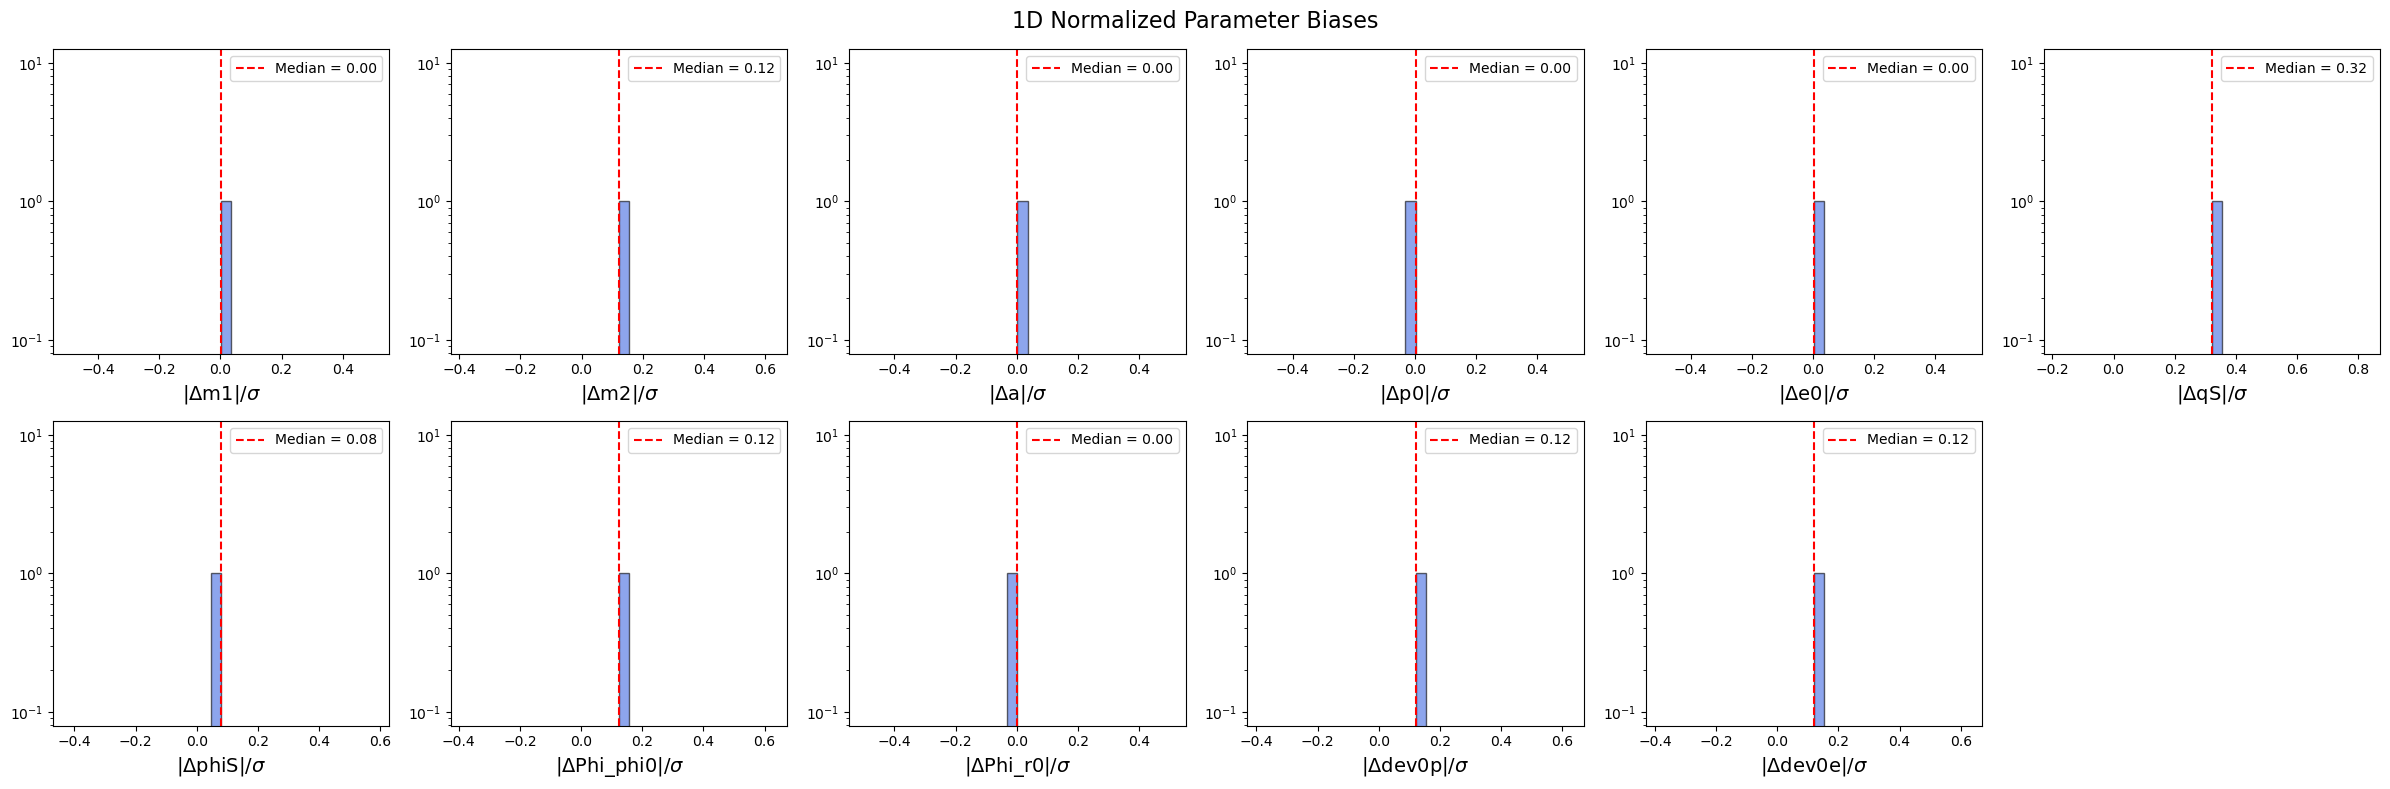

In [27]:
#used gpt (boring part)

# === PARAMETERS ===
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']


params_truth_in_considered = np.array([
    np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e
])
truevals_i = params_truth_in_considered

Fisher_transformed = Fisher_transform.copy()

# === REMOVE PARAMETERS IF SPECIFIED ===
rows_to_remove = [i for i, name in enumerate(param_names) if name in removed_params]
rows_to_remove = np.array(rows_to_remove)

if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=0)
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=1)
   # param_names_plot = np.delete(param_names_plot, rows_to_remove, axis=0)
    truevals_i = np.delete(truevals_i, rows_to_remove, axis=0)

# === COMPUTE SIGMAS ===
covariance = np.linalg.inv(Fisher_transformed)
sigmas_params = np.sqrt(np.diag(covariance))

# === COMPUTE NORMALIZED BIASES ===
sigmabias_1D = np.abs(biased_params - truevals_i) / sigmas_params

# === PLOT ===
n_params = len(param_names)
ncols = int(np.ceil(n_params / 2))

fig, axs = plt.subplots(2, ncols, figsize=(4 * ncols, 8))
axs = axs.flatten()

for i, name in enumerate(param_names):
    axs[i].hist(sigmabias_1D[i], bins=30, histtype='stepfilled',
                color='royalblue', alpha=0.6, edgecolor='k')
    axs[i].set_xlabel(r"$|\Delta $" + rf"{name}" + r"$|/\sigma$", fontsize=14)
    axs[i].set_yscale('log')
    axs[i].axvline(np.median(sigmabias_1D[i]), color='r', linestyle='--',
                   label=f"Median = {np.median(sigmabias_1D[i]):.2f}")
    axs[i].legend(fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("1D Normalized Parameter Biases", fontsize=16)
plt.show()



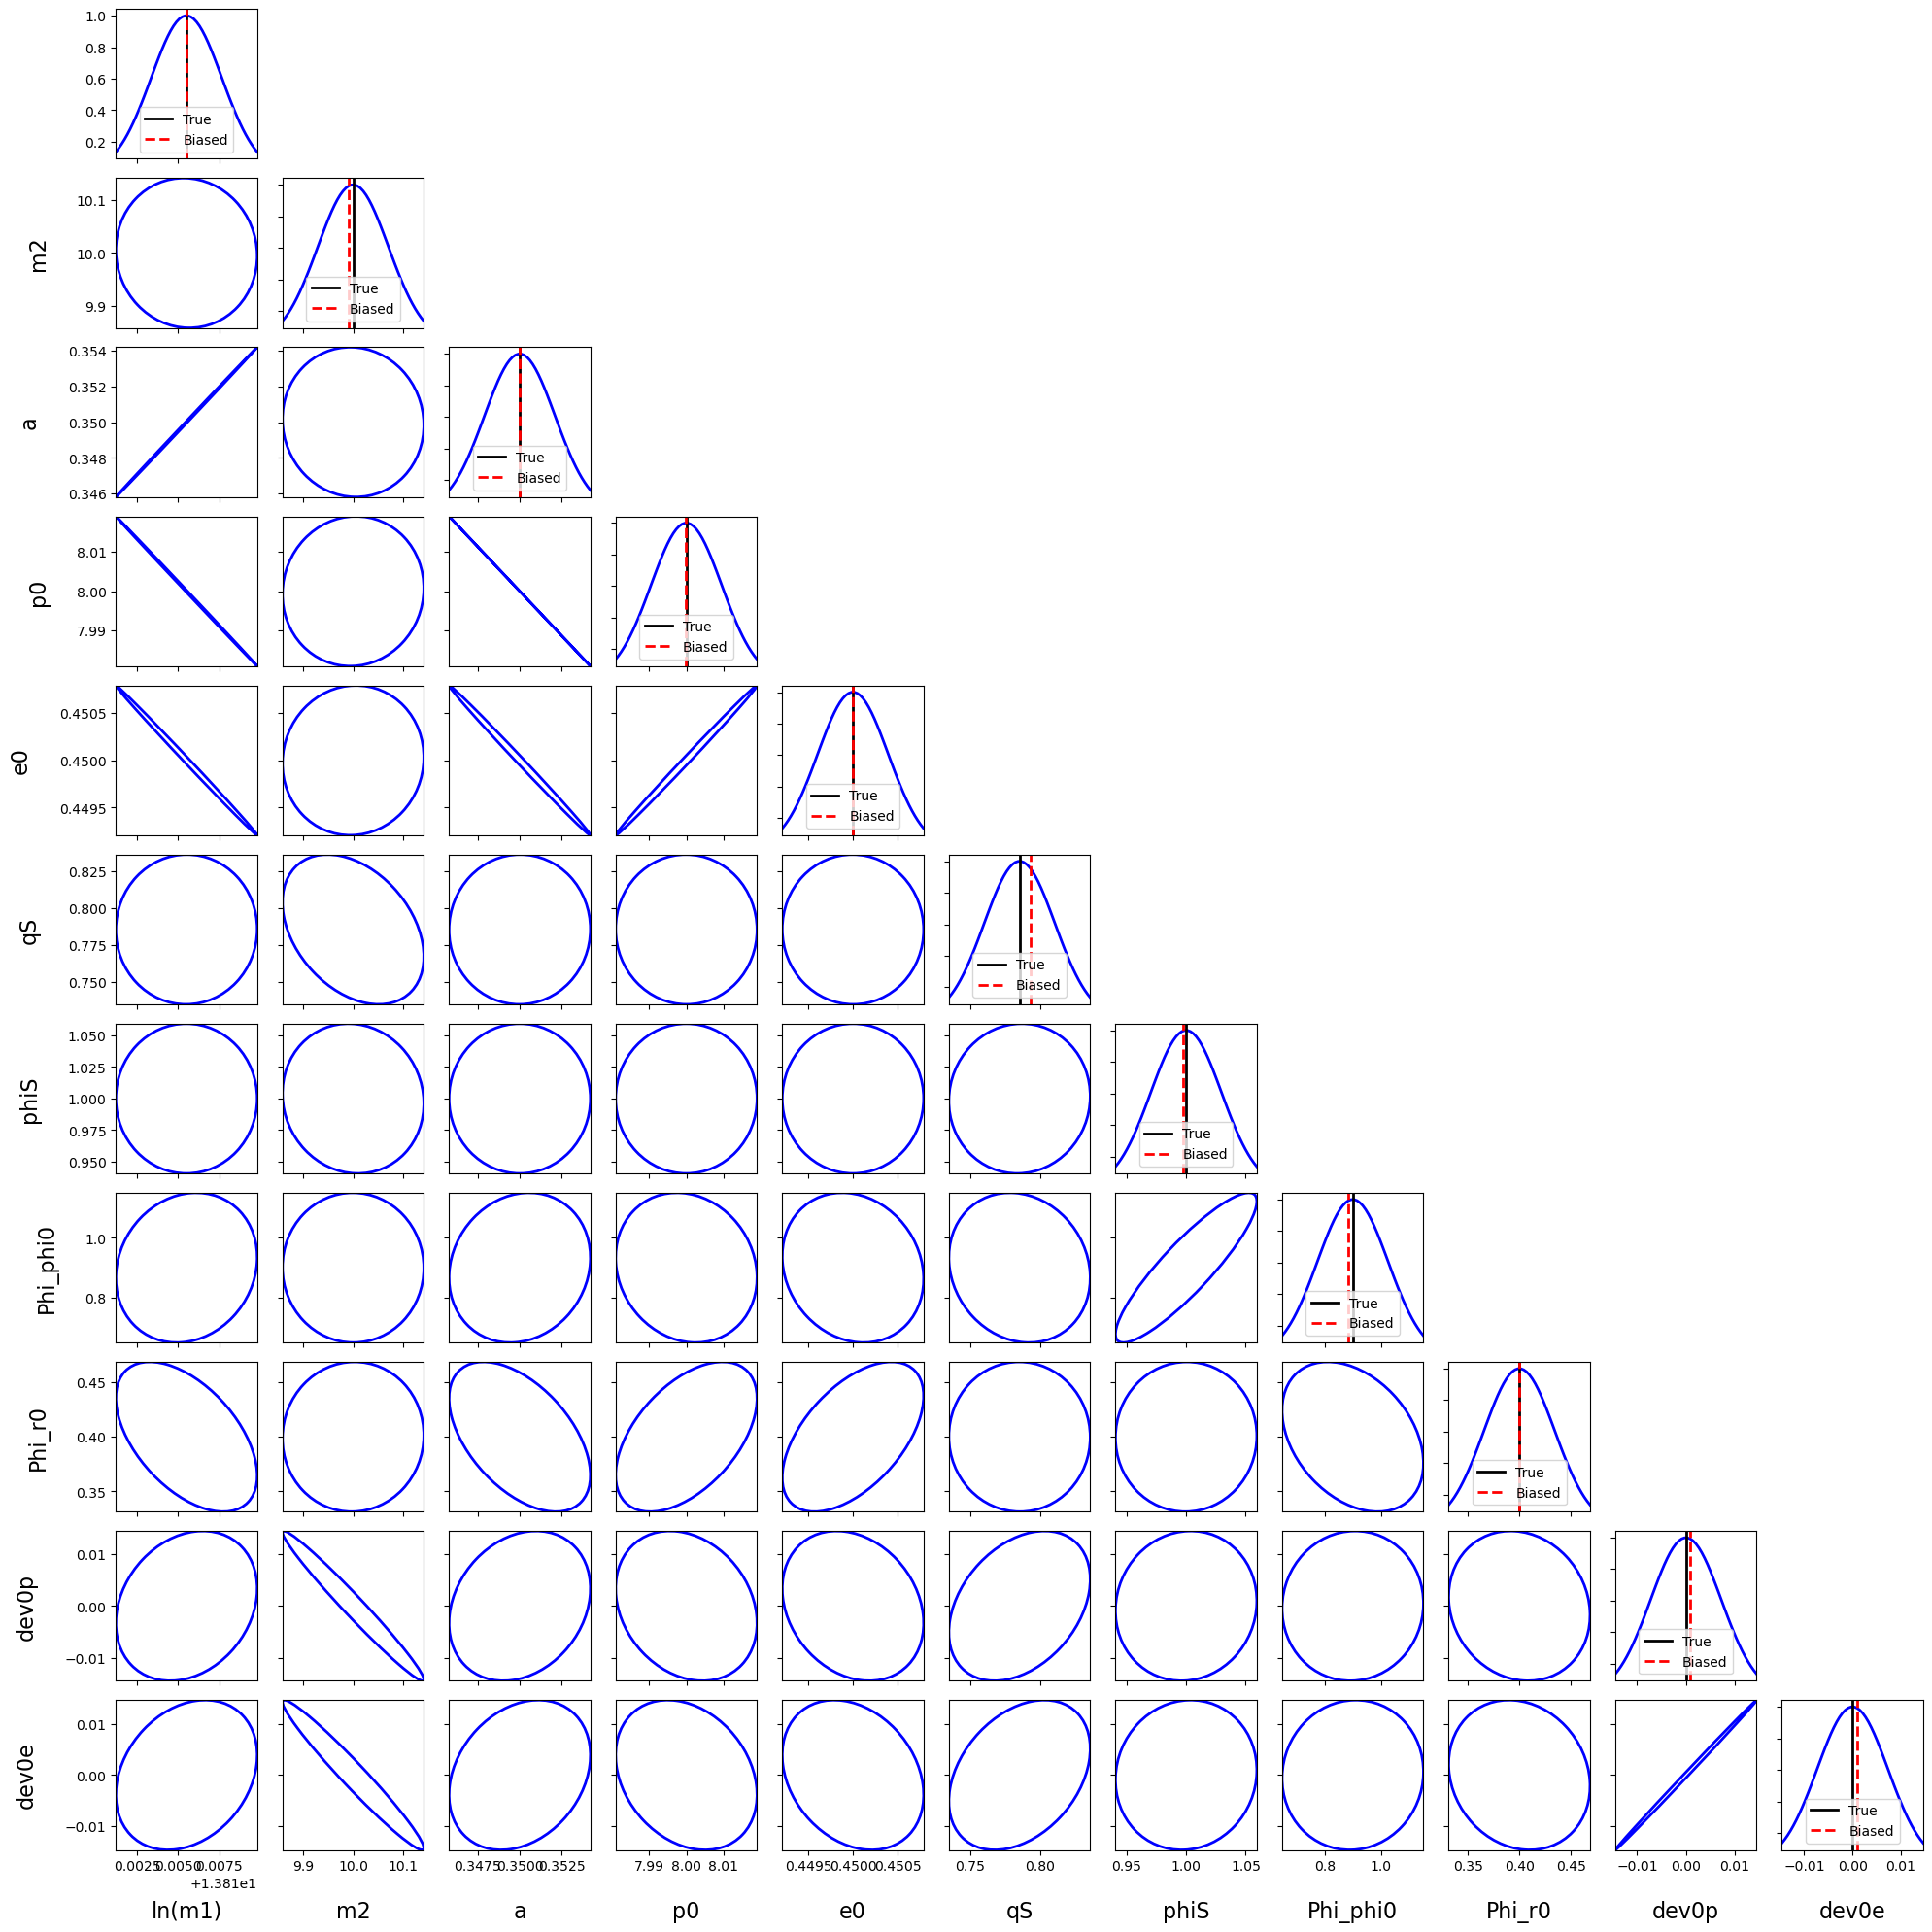

In [28]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in_considered
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in_considered[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in_considered[i], color='k', linestyle='-', lw=2, label='True')
    ax.axvline(biased_params[i], color='r', linestyle='--', lw=2, label='Biased')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [29]:
biased_params

array([1.38155153e+01, 9.99133144e+00, 3.50004713e-01, 7.99997862e+00,
       4.49999192e-01, 7.93549080e-01, 9.97637054e-01, 8.84307693e-01,
       3.99923166e-01, 8.69723387e-04, 8.69880688e-04])

In [30]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=biased_params[9]
dev_0_e=biased_params[10]
# param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [np.exp(biased_params[0]), biased_params[1], biased_params[2], biased_params[3], \
             biased_params[4], xI0, dist, biased_params[5], biased_params[6], qK, phiK, biased_params[7], Phi_theta0,\
               biased_params[8]]

superkludge_wave_biased = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

waveform_biased = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T)


In [31]:
deviation=params_truth_in_considered-biased_params
print("Higher",biased_params)
print("\nTrue",params_truth_in_considered)
print("\nlower",params_truth_in_considered+deviation)

Higher [1.38155153e+01 9.99133144e+00 3.50004713e-01 7.99997862e+00
 4.49999192e-01 7.93549080e-01 9.97637054e-01 8.84307693e-01
 3.99923166e-01 8.69723387e-04 8.69880688e-04]

True [13.81551056 10.          0.35        8.          0.45        0.78539816
  1.          0.9         0.4         0.          0.        ]

lower [ 1.38155058e+01  1.00086686e+01  3.49995287e-01  8.00002138e+00
  4.50000808e-01  7.77247247e-01  1.00236295e+00  9.15692307e-01
  4.00076834e-01 -8.69723387e-04 -8.69880688e-04]


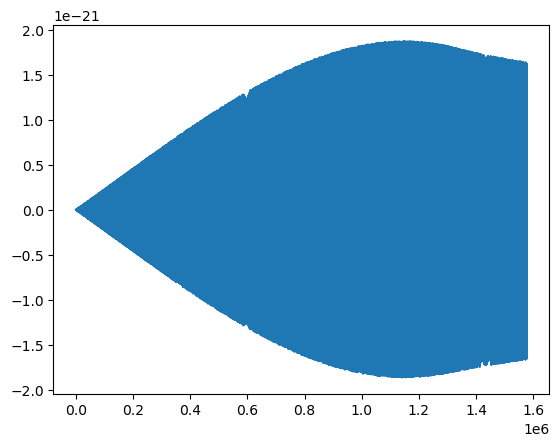

In [32]:
plt.plot((waveform_approx-waveform_true)[0].get())

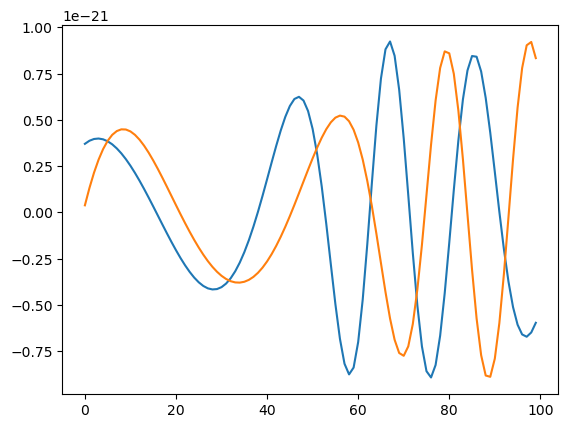

In [33]:
plt.plot((waveform_true)[0][-100:].get())
plt.plot((waveform_biased)[0][-100:].get())

In [34]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner=inner_product(waveform_biased,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_biased=np.sqrt(inner_product(waveform_biased,waveform_biased,PSD,dt,use_gpu=use_gpu))
diff_inner/((norm_true)*norm_biased)


np.float64(-0.1473005097893286)

In [35]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0

deviation=biased_params-params_truth_in_considered

PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])

norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
delta = np.linspace(-1,1,500)
save_inner=[]
for i in range(len(delta)):
    biased = params_truth_in_considered + delta[i] * deviation
    dev_0_p= biased[9]
    dev_0_e= biased[10]
    add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,\
                    "deviation_included":deviation_included,"dev0p":dev_0_p,
        "dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

    pars_list = [np.exp(biased[0]), biased[1], biased[2], biased[3], \
             biased[4], xI0, dist, biased[5], biased[6], qK, phiK, biased[7], Phi_theta0,\
               biased[8]]
    waveform_considered = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T,use_gpu=use_gpu)
    diff_inner=inner_product(waveform_considered,waveform_true,PSD,dt,use_gpu=use_gpu)
    norm_biased=np.sqrt(inner_product(waveform_considered,waveform_considered,PSD,dt,use_gpu=use_gpu))
    mismatch=diff_inner/((norm_true)*norm_biased)
   #print(mismatch)
    save_inner.append(mismatch)


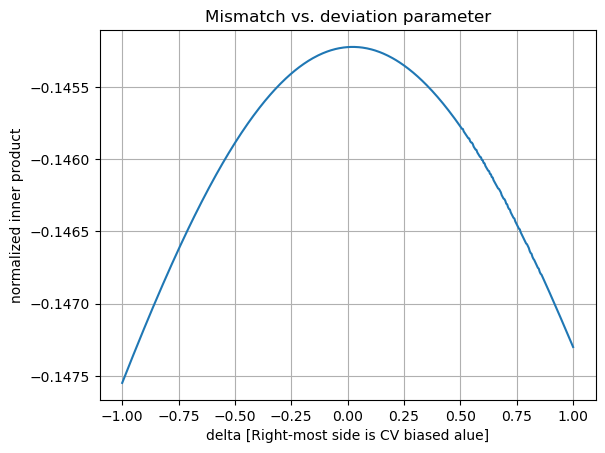

In [36]:
plt.plot(delta,save_inner)
plt.xlabel("delta [Right-most side is CV biased alue]")
plt.ylabel("normalized inner product")
plt.title("Mismatch vs. deviation parameter")
plt.grid(True)

In [37]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

-0.1452229458528422


np.float64(0.022044088176352616)

# ..
1. select mode to reduce noise